<a href="https://colab.research.google.com/github/GVK1999/Module-3-Coding-Assignment-GVK/blob/main/06_decision_trees_VamsiKrishnaGanesuni.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Chapter 6 – Decision Trees**

Name: Vamsi Krishna Ganesuni
Module 4 Assignment on Decision Trees

_This notebook contains all the sample code and solutions to the exercises in chapter 6._

<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/ageron/handson-ml3/blob/main/06_decision_trees.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
  </td>
  <td>
    <a target="_blank" href="https://kaggle.com/kernels/welcome?src=https://github.com/ageron/handson-ml3/blob/main/06_decision_trees.ipynb"><img src="https://kaggle.com/static/images/open-in-kaggle.svg" /></a>
  </td>
</table>

# Setup

This project requires Python 3.7 or above:

In [1]:
import sys

assert sys.version_info >= (3, 7)

It also requires Scikit-Learn ≥ 1.0.1:

In [2]:
from packaging import version
import sklearn

assert version.parse(sklearn.__version__) >= version.parse("1.0.1")

As we did in previous chapters, let's define the default font sizes to make the figures prettier:

In [3]:
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

And let's create the `images/decision_trees` folder (if it doesn't already exist), and define the `save_fig()` function which is used through this notebook to save the figures in high-res for the book:

In [4]:
from pathlib import Path

IMAGES_PATH = Path() / "images" / "decision_trees"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

# Exercise solutions

## 1. to 6.

1. The depth of a well-balanced binary tree containing _m_ leaves is equal to log₂(_m_), rounded up. log₂ is the binary log; log₂(_m_) = log(_m_) / log(2). A binary Decision Tree (one that makes only binary decisions, as is the case with all trees in Scikit-Learn) will end up more or less well balanced at the end of training, with one leaf per training instance if it is trained without restrictions. Thus, if the training set contains one million instances, the Decision Tree will have a depth of log₂(10<sup>6</sup>) ≈ 20 (actually a bit more since the tree will generally not be perfectly well balanced).
2. A node's Gini impurity is generally lower than its parent's. This is due to the CART training algorithm's cost function, which splits each node in a way that minimizes the weighted sum of its children's Gini impurities. However, it is possible for a node to have a higher Gini impurity than its parent, as long as this increase is more than compensated for by a decrease in the other child's impurity. For example, consider a node containing four instances of class A and one of class B. Its Gini impurity is 1 – (1/5)² – (4/5)² = 0.32. Now suppose the dataset is one-dimensional and the instances are lined up in the following order: A, B, A, A, A. You can verify that the algorithm will split this node after the second instance, producing one child node with instances A, B, and the other child node with instances A, A, A. The first child node's Gini impurity is 1 – (1/2)² – (1/2)² = 0.5, which is higher than its parent's. This is compensated for by the fact that the other node is pure, so its overall weighted Gini impurity is 2/5 × 0.5 + 3/5 × 0 = 0.2, which is lower than the parent's Gini impurity.
3. If a Decision Tree is overfitting the training set, it may be a good idea to decrease `max_depth`, since this will constrain the model, regularizing it.
4. Decision Trees don't care whether or not the training data is scaled or centered; that's one of the nice things about them. So if a Decision Tree underfits the training set, scaling the input features will just be a waste of time.
5. The computational complexity of training a Decision Tree is _O_(_n_ × _m_ log₂(_m_)). So if you multiply the training set size by 10, the training time will be multiplied by _K_ = (_n_ × 10 _m_ × log₂(10 _m_)) / (_n_ × _m_ × log₂(_m_)) = 10 × log₂(10 _m_) / log₂(_m_). If _m_ = 10<sup>6</sup>, then _K_ ≈ 11.7, so you can expect the training time to be roughly 11.7 hours.
6. If the number of features doubles, then the training time will also roughly double.

## 7.

_Exercise: train and fine-tune a Decision Tree for the moons dataset._

a. Generate a moons dataset using `make_moons(n_samples=10000, noise=0.4)`.

Adding `random_state=42` to make this notebook's output constant:

In [5]:
from sklearn.datasets import make_moons

X_moons, y_moons = make_moons(n_samples=10000, noise=0.4, random_state=42)

b. Split it into a training set and a test set using `train_test_split()`.

The data is split into a training set and a test set so the model can learn from the training data and then be tested on data it has not seen before. This helps us measure how well the model can make predictions on new data and helps identify whether the model is overfitting.

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_moons, y_moons,
                                                    test_size=0.2,
                                                    random_state=42)

c. Use grid search with cross-validation (with the help of the `GridSearchCV` class) to find good hyperparameter values for a `DecisionTreeClassifier`. Hint: try various values for `max_leaf_nodes`.

In [9]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

params = {
    'max_leaf_nodes': list(range(2, 100)),
    'max_depth': list(range(1, 7)),
    'min_samples_split': [2, 3, 4]
}
grid_search_cv = GridSearchCV(DecisionTreeClassifier(random_state=42),
                              params,
                              cv=3)

grid_search_cv.fit(X_train, y_train)

GridSearchCV(cv=3, estimator=DecisionTreeClassifier(random_state=42),
             param_grid={'max_depth': [1, 2, 3, 4, 5, 6],
                         'max_leaf_nodes': [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12,
                                            13, 14, 15, 16, 17, 18, 19, 20, 21,
                                            22, 23, 24, 25, 26, 27, 28, 29, 30,
                                            31, ...],
                         'min_samples_split': [2, 3, 4]})

In [10]:
grid_search_cv.best_estimator_

DecisionTreeClassifier(max_depth=6, max_leaf_nodes=17, random_state=42)

d. Train it on the full training set using these hyperparameters, and measure your model's performance on the test set. You should get roughly 85% to 87% accuracy.

The suggested hyperparameter values are max_leaf_nodes = 17 and min_samples_split = 2. These values give a test accuracy of approximately 86%, which is within the expected 85% to 87% range.

By default, `GridSearchCV` trains the best model found on the whole training set (you can change this by setting `refit=False`), so we don't need to do it again. We can simply evaluate the model's accuracy:

In [11]:
from sklearn.metrics import accuracy_score

y_pred = grid_search_cv.predict(X_test)
accuracy_score(y_test, y_pred)

0.8595

### Visualize the Best Decision Tree

Let's visualize the structure of the best Decision Tree found by `GridSearchCV` to understand its decision-making process. The `feature_names` are set to `Feature 1` and `Feature 2` and `class_names` to `Class 0` and `Class 1` for the moons dataset.

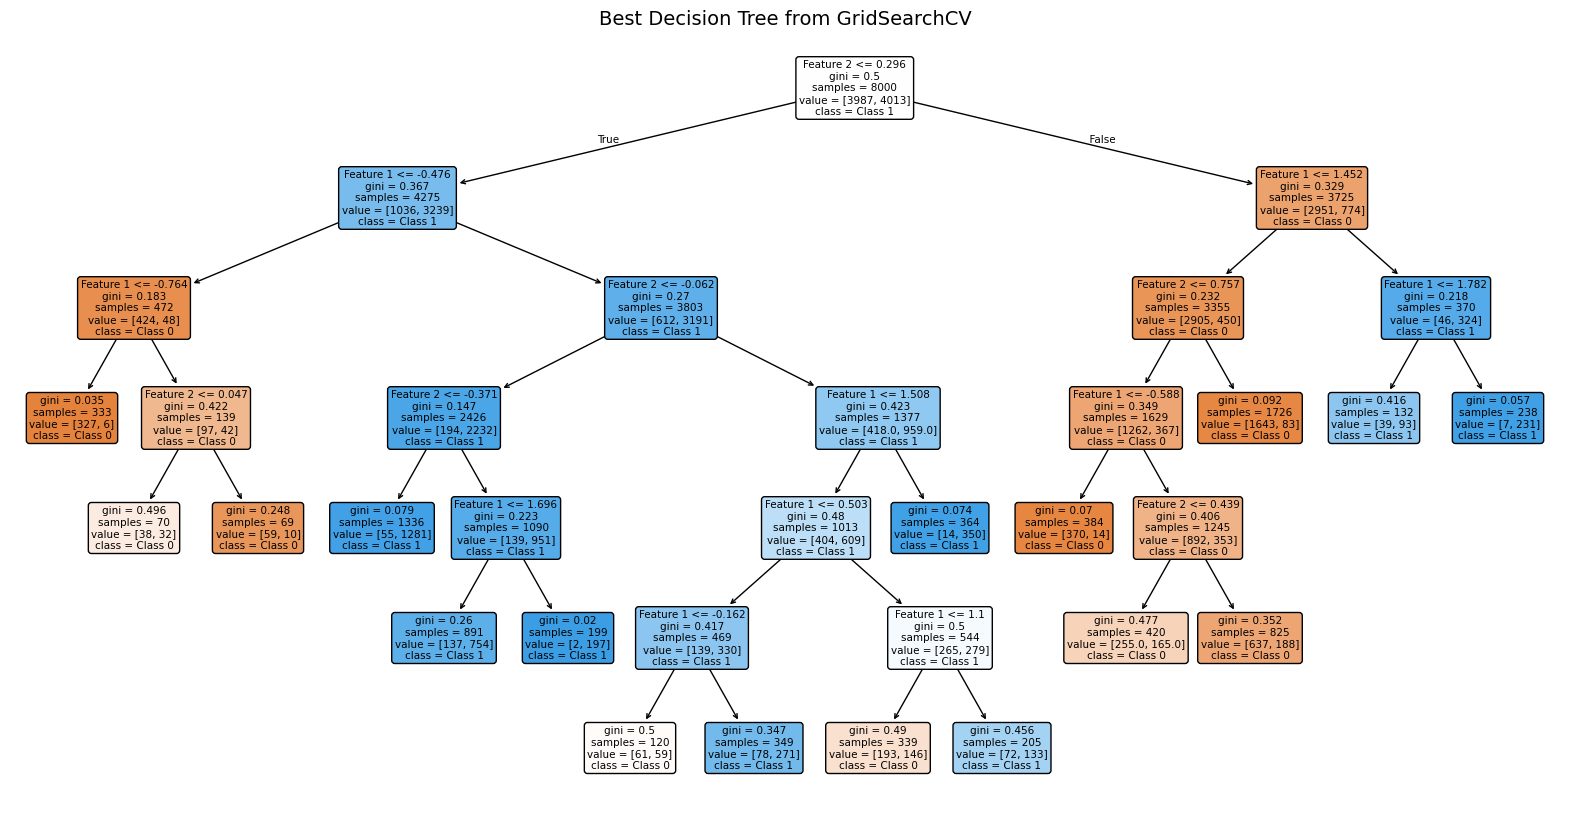

In [18]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10)) # Adjust figure size for better readability
plot_tree(grid_search_cv.best_estimator_,
          filled=True,
          rounded=True,
          feature_names=['Feature 1', 'Feature 2'], # Appropriate for the moons dataset
          class_names=['Class 0', 'Class 1'])
plt.title("Best Decision Tree from GridSearchCV")
plt.show()

## 8.

_Exercise: Grow a forest._

a. Continuing the previous exercise, generate 1,000 subsets of the training set, each containing 100 instances selected randomly. Hint: you can use Scikit-Learn's `ShuffleSplit` class for this.

In [12]:
from sklearn.model_selection import ShuffleSplit

n_trees = 1000
n_instances = 100

mini_sets = []

rs = ShuffleSplit(n_splits=n_trees, test_size=len(X_train) - n_instances,
                  random_state=42)

for mini_train_index, mini_test_index in rs.split(X_train):
    X_mini_train = X_train[mini_train_index]
    y_mini_train = y_train[mini_train_index]
    mini_sets.append((X_mini_train, y_mini_train))

b. Train one Decision Tree on each subset, using the best hyperparameter values found above. Evaluate these 1,000 Decision Trees on the test set. Since they were trained on smaller sets, these Decision Trees will likely perform worse than the first Decision Tree, achieving only about 80% accuracy.

These Decision Trees will likely perform worse because each tree is trained on a much smaller subset of the training data. With fewer examples, each tree has less information to learn the patterns in the data. Therefore, the individual trees may make more mistakes when predicting the test data, resulting in lower accuracy of about 80%.


In [14]:
from sklearn.base import clone
import numpy as np

forest = [clone(grid_search_cv.best_estimator_) for _ in range(n_trees)]

accuracy_scores = []

for tree, (X_mini_train, y_mini_train) in zip(forest, mini_sets):
    tree.fit(X_mini_train, y_mini_train)

    y_pred = tree.predict(X_test)
    accuracy_scores.append(accuracy_score(y_test, y_pred))

np.mean(accuracy_scores)

np.float64(0.8056605)

c. Now comes the magic. For each test set instance, generate the predictions of the 1,000 Decision Trees, and keep only the most frequent prediction (you can use SciPy's `mode()` function for this). This gives you _majority-vote predictions_ over the test set.

In [15]:
Y_pred = np.empty([n_trees, len(X_test)], dtype=np.uint8)

for tree_index, tree in enumerate(forest):
    Y_pred[tree_index] = tree.predict(X_test)

In [16]:
from scipy.stats import mode

y_pred_majority_votes, n_votes = mode(Y_pred, axis=0)

d. Evaluate these predictions on the test set: you should obtain a slightly higher accuracy than your first model (about 0.5 to 1.5% higher). Congratulations, you have trained a Random Forest classifier!

In [17]:
accuracy_score(y_test, y_pred_majority_votes.reshape([-1]))

0.873

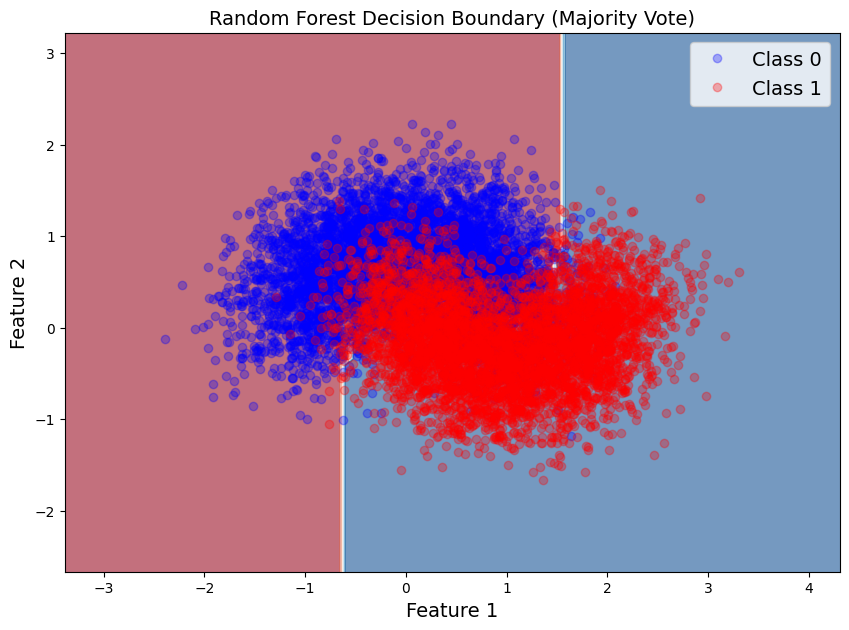

In [19]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import mode

def random_forest_predict(X_new, forest):
    """
    Computes the majority vote predictions from an ensemble of Decision Trees.
    """
    # Get predictions from each tree in the forest for the new data points
    all_predictions = np.array([tree.predict(X_new) for tree in forest])
    # For each data point, find the majority vote among all tree predictions
    majority_votes, _ = mode(all_predictions, axis=0)
    return majority_votes.ravel()

# Define the ranges for the plot based on the X_moons dataset
x1_min, x1_max = X_moons[:, 0].min() - 1, X_moons[:, 0].max() + 1
x2_min, x2_max = X_moons[:, 1].min() - 1, X_moons[:, 1].max() + 1

# Create a meshgrid to cover the entire feature space
x1s = np.linspace(x1_min, x1_max, 100)
x2s = np.linspace(x2_min, x2_max, 100)
x1, x2 = np.meshgrid(x1s, x2s)
X_new_meshgrid = np.c_[x1.ravel(), x2.ravel()]

# Get predictions from the overall random forest using the majority vote
y_pred_rf = random_forest_predict(X_new_meshgrid, forest).reshape(x1.shape)

# Plot the decision boundary
plt.figure(figsize=(10, 7))
plt.contourf(x1, x2, y_pred_rf, cmap=plt.cm.RdBu, alpha=0.6)

# Plot the original data points
plt.plot(X_moons[y_moons == 0, 0], X_moons[y_moons == 0, 1], "bo", alpha=0.3, label="Class 0")
plt.plot(X_moons[y_moons == 1, 0], X_moons[y_moons == 1, 1], "ro", alpha=0.3, label="Class 1")

plt.title("Random Forest Decision Boundary (Majority Vote)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()

3.Reflection

1. Give two real-world business or technology applications that you can use Decision Trees?

One application of Decision Trees is email spam detection, where the model can classify emails as spam or not spam. Another application is loan approval, where a bank can use information such as income, credit history, and debt to help classify loan applications.

2. What is overfitting?

Overfitting happens when a model learns the training data too closely, including unnecessary details or noise. As a result, the model may perform very well on the training data but not perform as well on new data.

3. Write a statement on how you used AI in this assignment.

I used AI to help me understand Decision Tree concepts, fix coding errors, and create code for visualizing the Decision Tree and Random Forest decision boundary. I also used AI to help explain the results and understand the concepts better.